In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from SupernovaDataset.dataset_creation import create_synthetic_supernovae_dataset, create_torch_supernovae_dataset
from SupernovaDataset.config import DATA_VARIANCE_SCALE, LOAD_DATASET, NUM_TRAIN, NUM_TEST, DATAPOINT_SIZE, LATENT_SIZE

from Compression.ib import IB
from Compression.compressors import IBCompressor
from Compression.conditional_prob_models import ConditionalKDE
from Compression.Benchmarks.MOPED import moped

from true_mi import supernova_mi
from ba_bound import supernova_ba_bound

In [5]:
FLUX_SCALE = 1e10
z_obs = np.linspace(0.01, 10.0, DATAPOINT_SIZE)

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on device:", device)

Running on device: cuda


In [7]:
if LOAD_DATASET:
    try:
        train_sims_data = torch.load("train_sims_data.pt")
        test_sims_data = torch.load("test_sims_data.pt")
    except FileNotFoundError:
        print("Data files not found. Creating dataset...")
        train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, 1000)
        torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
        torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")
else:
    train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, 1000)
    torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
    torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")

train_sims_data = train_sims_data.to(device)
train_sims_data[:, -1] = train_sims_data[:, -1] ** 2  # Square the last column (h0) for training
test_sims_data = test_sims_data.to(device)
test_sims_data[:, -1] = test_sims_data[:, -1] ** 2  # Square the last column (h0) for testing

In [8]:
def simulate(h0=1.):
    dist_mod= create_synthetic_supernovae_dataset(
        n_samples=1,
        h0s=[h0],
        print_status=False,
        data_var=DATA_VARIANCE_SCALE
        )[1]
    return FLUX_SCALE*10**(-0.4*dist_mod)


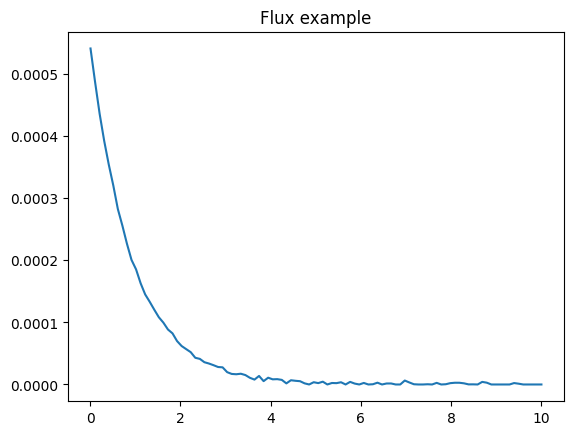

In [9]:
d_obs = simulate(h0=70.0)

plt.plot(z_obs, d_obs.T)
plt.title("Flux example")
plt.show()

In [10]:
true_mi = supernova_mi(simulate=simulate, prior_var=5., cond_var=DATA_VARIANCE_SCALE)
print(f'The true I(F, H0^2) = {true_mi}')

[[1.00000000e-14 3.13055189e-06 1.88334725e-07 1.00000000e-14
  4.94141678e-06 1.44702849e-06 8.40446150e-07 3.54895108e-06
  6.00010649e-07 1.00000000e-14 2.06196273e-06 1.05704121e-06
  9.24913338e-07 1.00000000e-14 1.00000000e-14 1.00000000e-14
  7.75221477e-07 1.00000000e-14 1.00000000e-14 1.69633103e-07
  1.00000000e-14 1.02777388e-06 1.99020468e-06 1.00000000e-14
  2.93133721e-06 3.15778904e-06 1.00000000e-14 1.00000000e-14
  2.96127541e-06 1.00000000e-14 1.60573702e-06 2.65128297e-07
  1.00000000e-14 1.00000000e-14 8.48706504e-07 1.00000000e-14
  1.00000000e-14 1.00000000e-14 1.00000000e-14 1.00000000e-14
  1.00000000e-14 2.02761145e-06 1.00000000e-14 2.59493779e-06
  5.21157084e-06 1.00000000e-14 1.00000000e-14 1.39921736e-06
  1.00000000e-14 1.20396186e-06 1.00000000e-14 1.00000000e-14
  1.00000000e-14 1.00000000e-14 2.76508665e-06 1.00000000e-14
  1.02010381e-06 1.29215199e-06 1.00000000e-14 1.00000000e-14
  1.00000000e-14 2.26880883e-06 2.65234114e-06 1.00000000e-14
  1.0000

In [11]:
a

NameError: name 'a' is not defined

In [ ]:
class MOPEDCompressor(nn.Module):
    def __init__(self, device=device):
        super().__init__()
        self.b = None
        self.device = device
    def train_MOPED(self, fid_vals, cov, estimator_given_theta):
        self.b, self.F, self.d = moped(fid_vals, cov, estimator_given_theta)
        plt.plot(z_obs, self.b.T)
        plt.xlabel('Observed Redshift')
        plt.ylabel('Weight')
        plt.title('MOPED Weights for Supernovae Dataset')
        plt.show()
        self.b = torch.tensor(self.b, dtype=torch.float32).to(self.device)
    
    def forward(self, x):
        x=FLUX_SCALE*10**(-0.4*x)
        mean = x @ self.b.T
        return mean, torch.zeros_like(mean, dtype=torch.float32).to(self.device), mean

In [ ]:
model_encoder=nn.Sequential(
            nn.Linear(DATAPOINT_SIZE, 256),
            # nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            # nn.Dropout(0.1),
            
            nn.Linear(256, 128),
            # nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(128, 64),
            # nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            # nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(32, 2*LATENT_SIZE)
        )
model = IB(
    # encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
    encoder=MOPEDCompressor(device=device),
    cond_prob_model=ConditionalKDE(1, 10),
    # cond_prob_model=ConditionalNormalizingFlow(),
    beta = 0e-2,
    reg_weight=0.1,
    reg_type=0,
    optim_func=torch.optim.SGD,
    lr=1e-4
).to(device)


In [ ]:
def moped_simulate(theta):
    z_obs, data, _, _ = create_synthetic_supernovae_dataset(1, theta, data_var=0., print_status=False)
    # plt.scatter(z_obs,data[0, :])
    # plt.show()
    # print(data.shape)
    return FLUX_SCALE*10**(-0.4*data[0, :])

(1, 100)


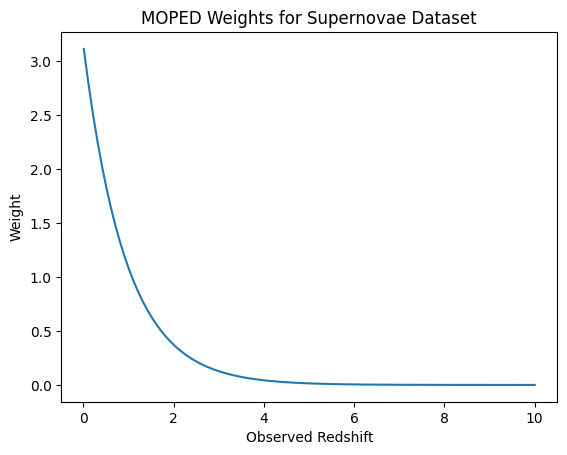

In [ ]:
cov = np.eye(DATAPOINT_SIZE) * DATA_VARIANCE_SCALE
fid_vals = np.array([70.0])
model.encoder.train_MOPED(fid_vals, cov, moped_simulate)

In [ ]:
ba_bounds = []

Epoch 0: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 10: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 20: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 30: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 40: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000


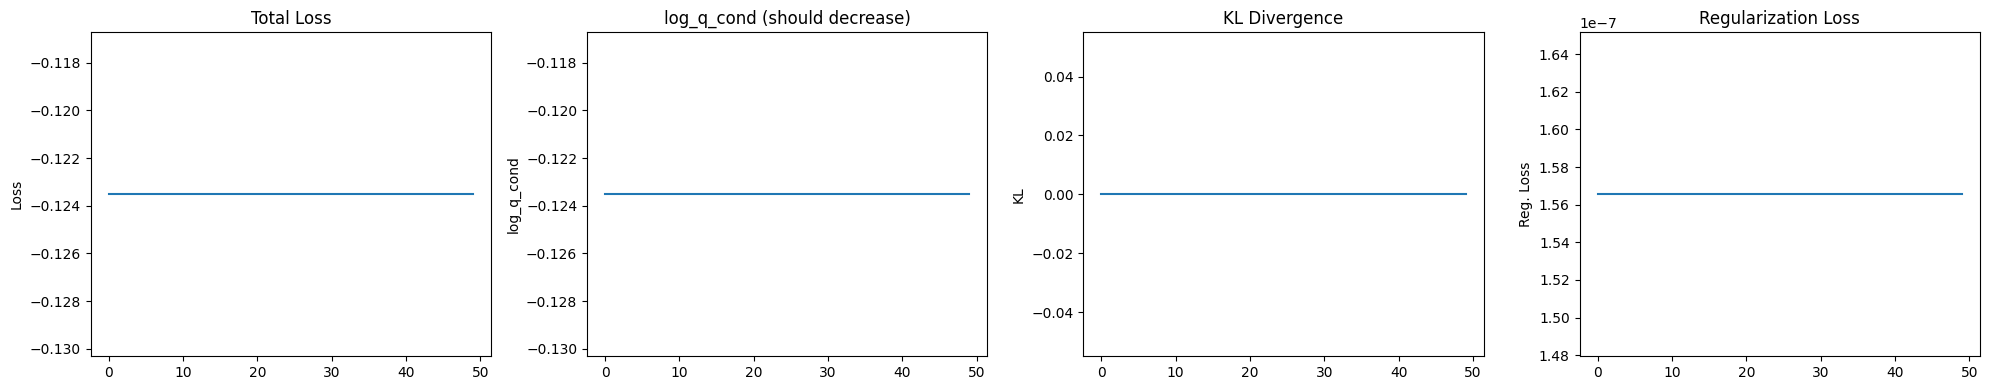

Epoch 0: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 10: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 20: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 30: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 40: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000


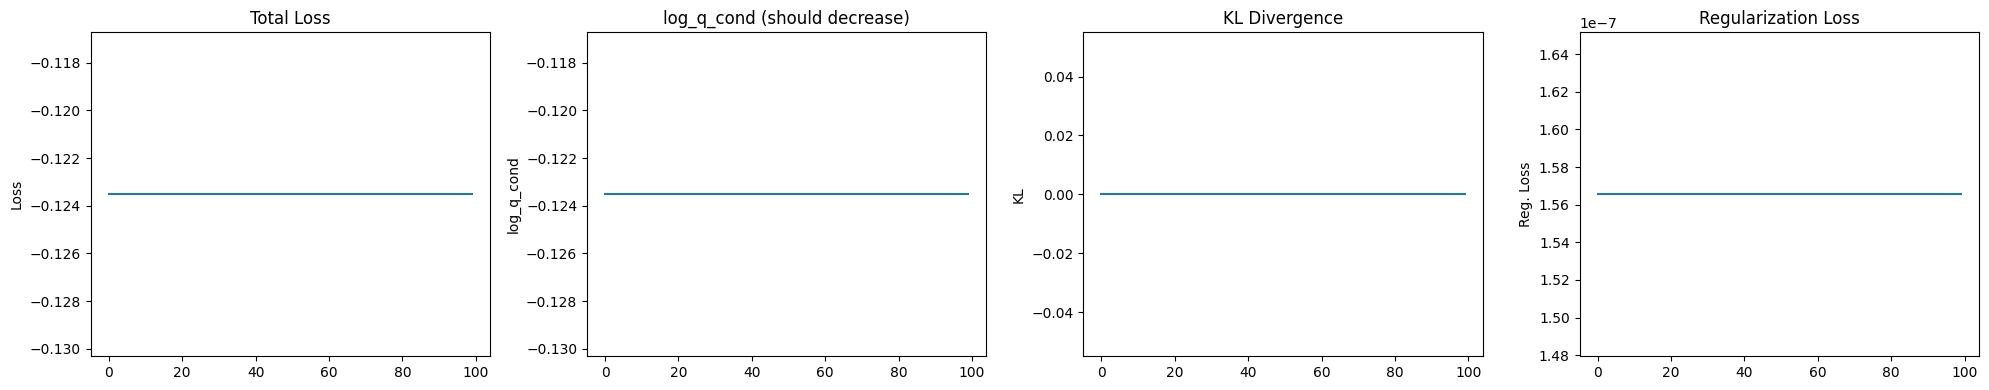

Epoch 0: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 10: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 20: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 30: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 40: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000


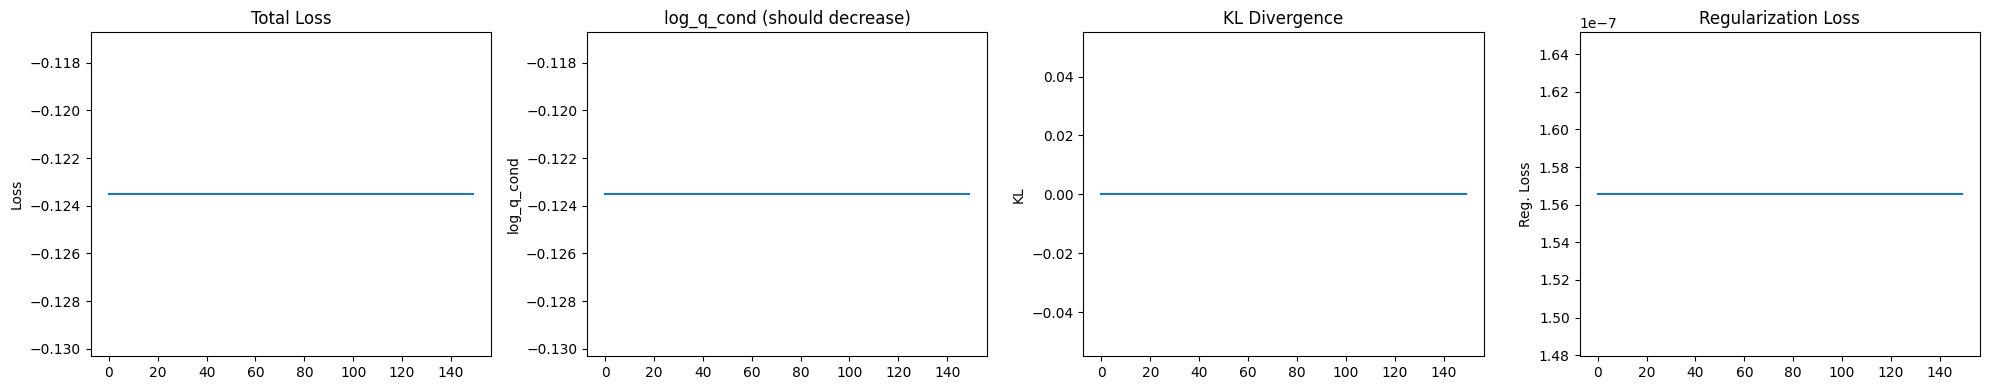

Epoch 0: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 10: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 20: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 30: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 40: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000


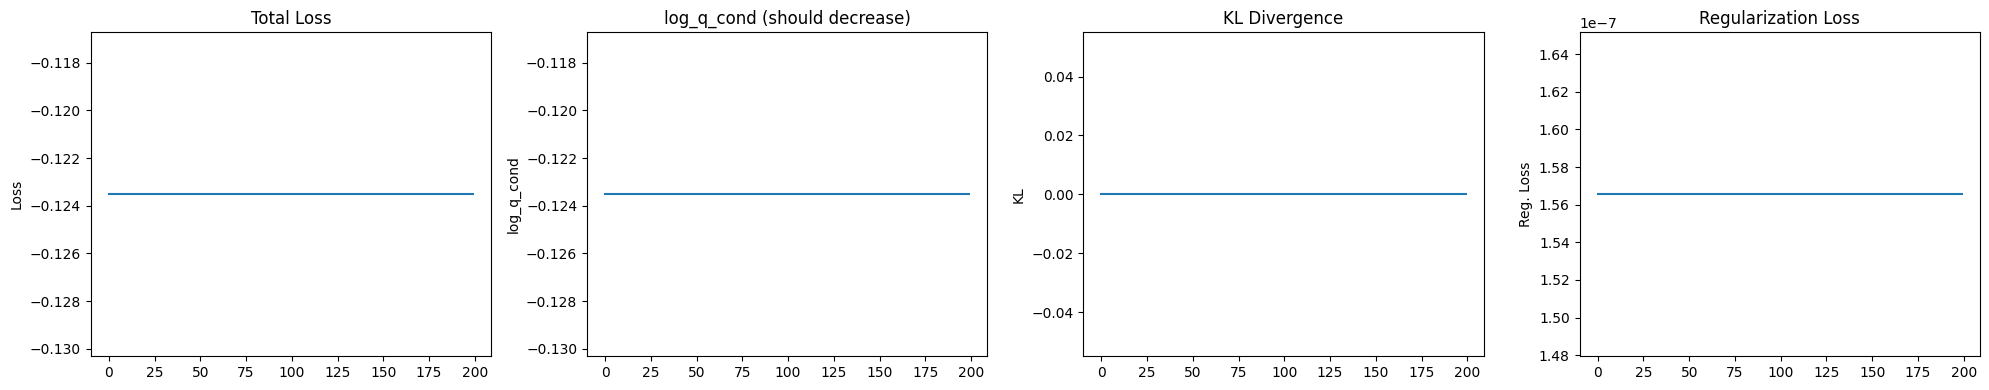

Epoch 0: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 10: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 20: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 30: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 40: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000


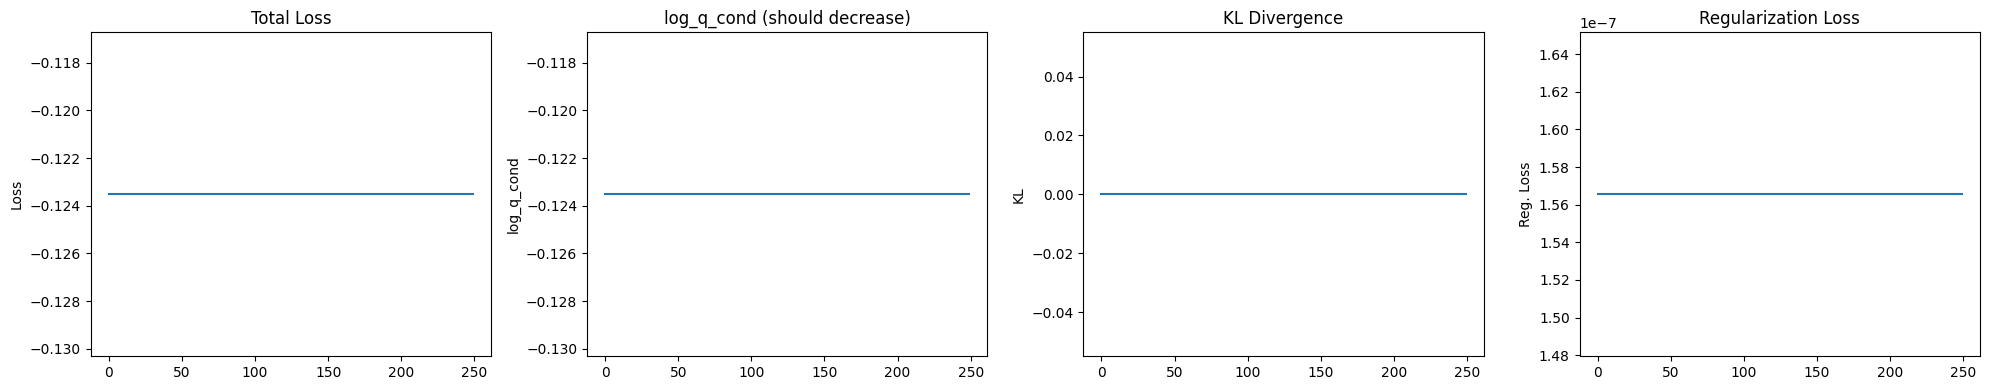

Epoch 0: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 10: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 20: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 30: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 40: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000


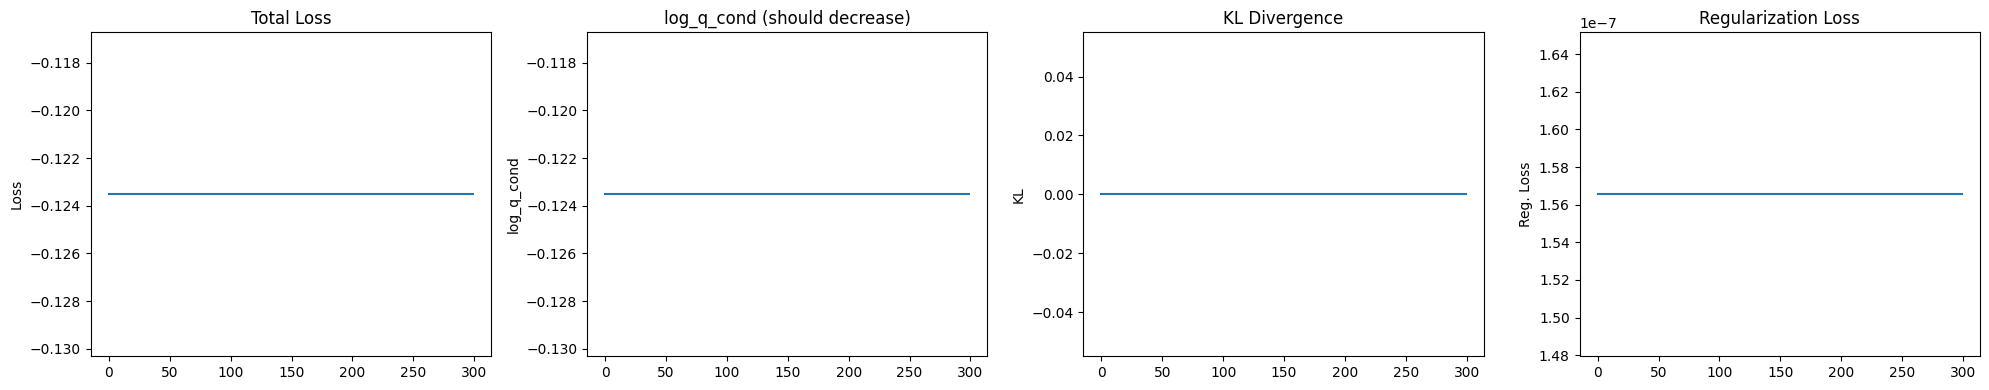

Epoch 0: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 10: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 20: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 30: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 40: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000


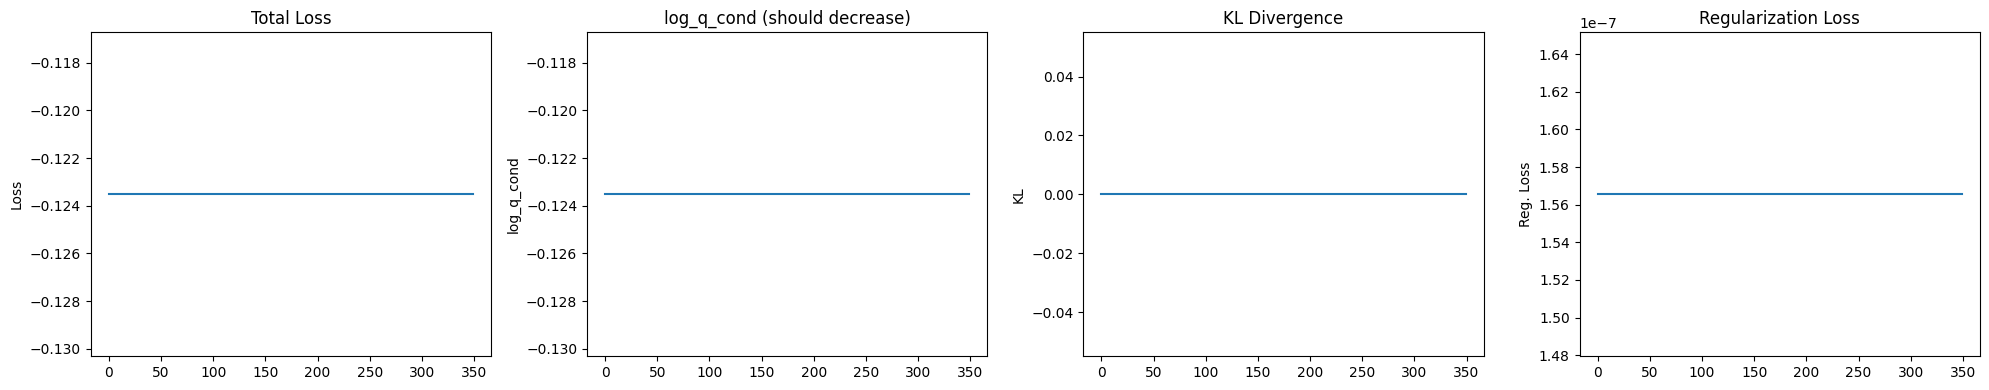

Epoch 0: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 10: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 20: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 30: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 40: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000


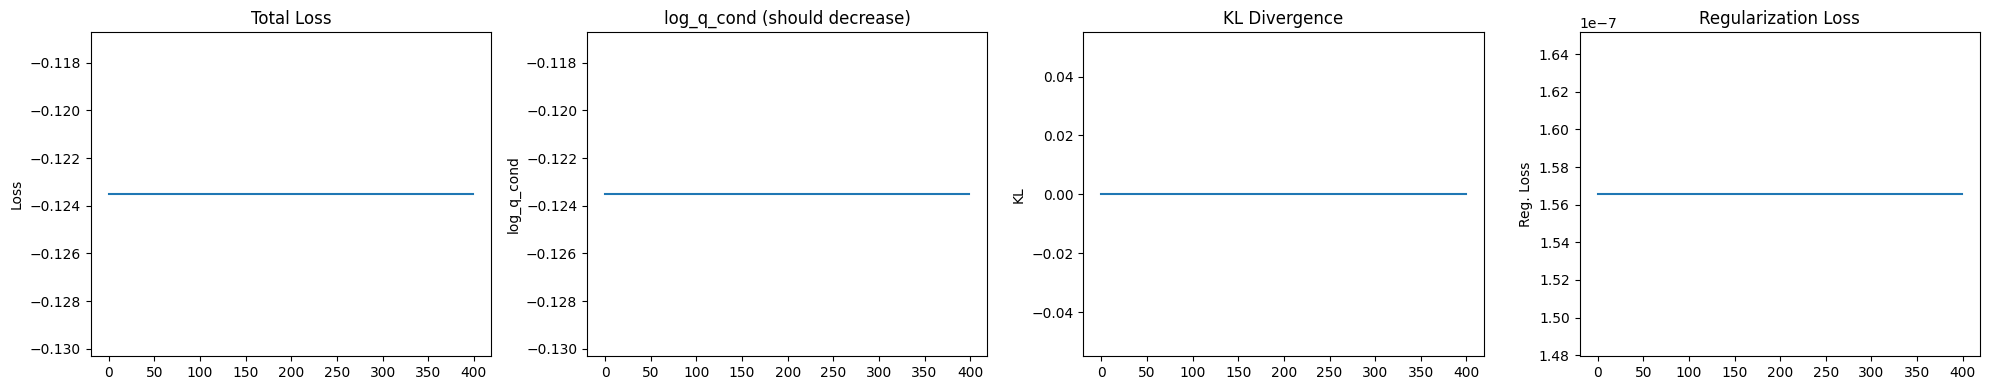

Epoch 0: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 10: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 20: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 30: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 40: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000


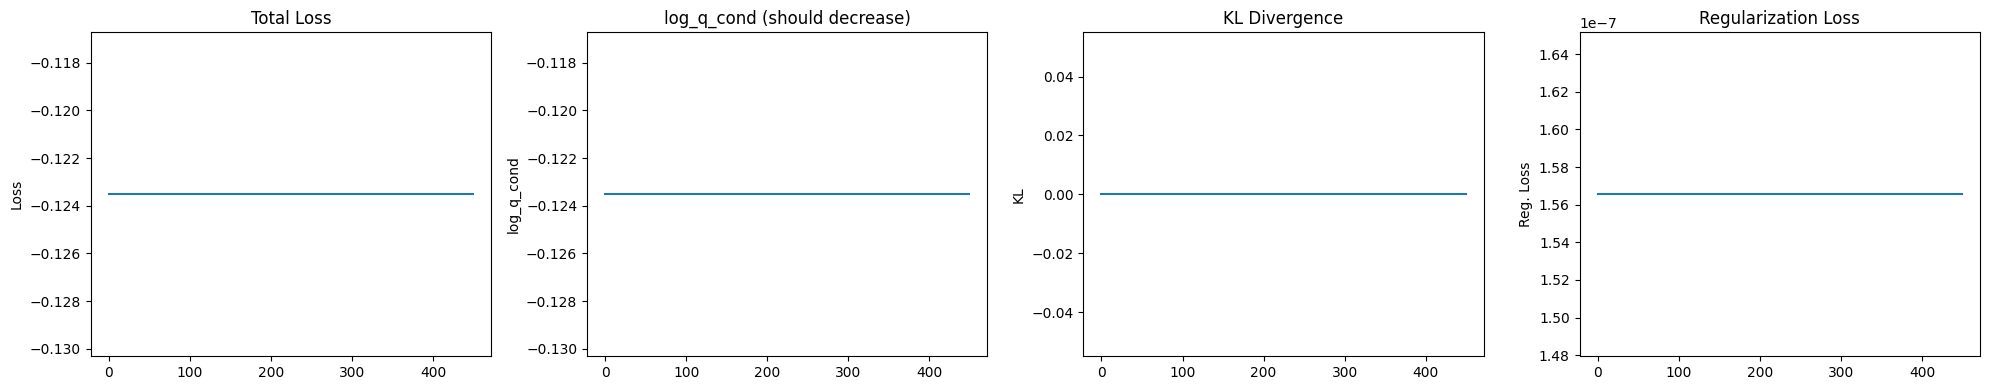

Epoch 0: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 10: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 20: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 30: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000
Epoch 40: Loss=-0.1235, log_q=-0.1235,, reg. loss=0.0000, KL=0.0000


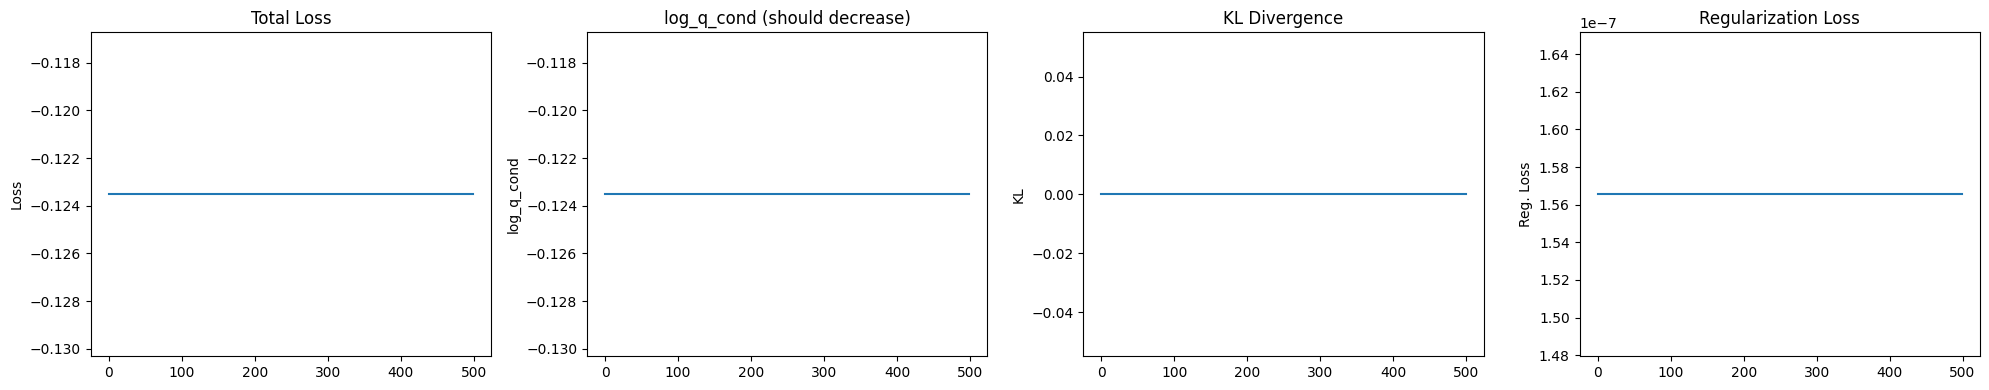

In [ ]:
for _ in range(10):
    model.train(
        x_train=train_sims_data[:, :DATAPOINT_SIZE],
        y_train=train_sims_data[:, -1],
        nepochs=50,
        print_losses=True
    )
    compressed_data = model.encoder(train_sims_data[:, :DATAPOINT_SIZE])[-1]
    ba_bounds.append(supernova_ba_bound(model.cond_prob_model, compressed_data, train_sims_data[:, -1]).item())

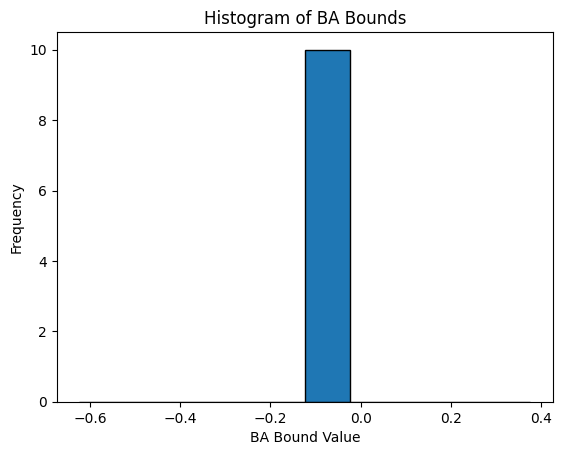

In [ ]:
plt.hist(ba_bounds, edgecolor='black', density=True)
plt.title("Histogram of BA Bounds")
plt.xlabel("BA Bound Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
model.full_losses[-1]

-0.11573271453380585

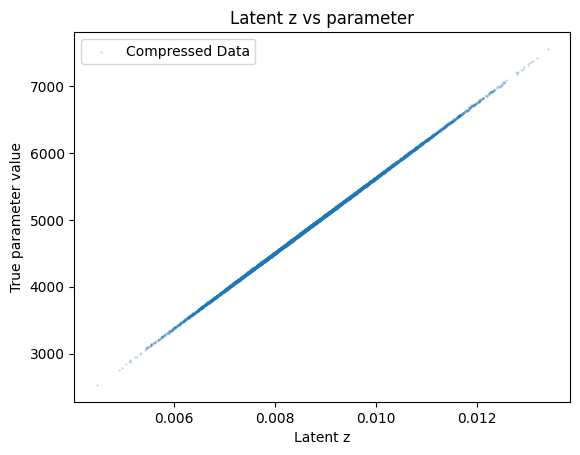

In [ ]:
m, l, z = model.encoder(train_sims_data[:, :DATAPOINT_SIZE])
z = z.detach().cpu().numpy()

plt.scatter(z, train_sims_data[:, -1].cpu().numpy(), alpha=0.5, s=1e-1, label='Compressed Data')
plt.xlabel('Latent z')
plt.ylabel('True parameter value')
plt.legend()
# plt.xlim([2e-12, 2.5e-12])
# plt.ylim([65, 75])
plt.title('Latent z vs parameter')
plt.show()

z_min=0.004479799885302782, z_max=0.013402821496129036


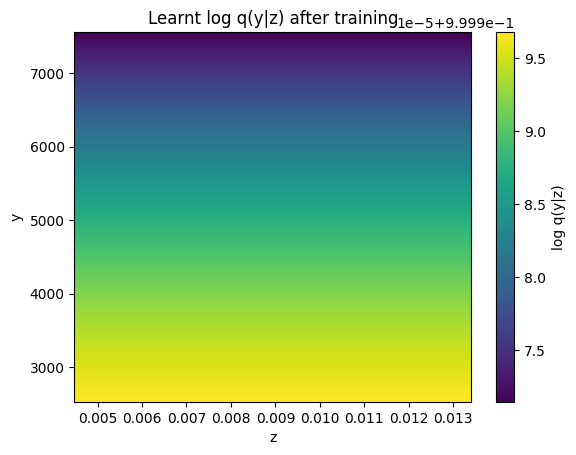

In [ ]:
z_max = model.encoder(train_sims_data[:, :DATAPOINT_SIZE])[-1].max().item()
z_min = model.encoder(train_sims_data[:, :DATAPOINT_SIZE])[-1].min().item()
print(f'{z_min=}, {z_max=}')
y_min = train_sims_data[:, -1].min().item()
y_max = train_sims_data[:, -1].max().item()

ys = np.linspace(y_min, y_max, 1000)
zs = np.linspace(z_min, z_max, 1000)

yz_grid = torch.tensor([[y, z] for y in ys for z in zs], dtype=torch.float32).to(device)

log_q_values = model.cond_prob_model.log_prob(yz_grid[:, 0:1], yz_grid[:, 1:2])
q_values = torch.exp(log_q_values)
plt.imshow(q_values.detach().cpu().numpy().reshape(1000, 1000), extent=(z_min, z_max, y_min, y_max), origin='lower', aspect='auto')
plt.colorbar(label='log q(y|z)')
plt.title("Learnt log q(y|z) after training")
plt.xlabel("z")
plt.ylabel("y")
plt.show()